# FASE 1 - EDA y Preparacion
## Proyecto Cardiologia Analytics

**Dataset:** Heart Failure Prediction (918 pacientes, 12 variables).

Objetivos de esta fase:
1. Cargar e inspeccionar el dataset.
2. Auditar la calidad de los datos (nulos, duplicados, ceros imposibles).
3. Limpiar e imputar errores de captura clinicos.
4. Crear etiquetas legibles para el dashboard (Power BI).
5. Inyectar variables de negocio: `ID_Paciente` y `Costo_Tratamiento_USD`.
6. Generar un reporte descriptivo con lectura clinico-hospitalaria.
7. Exportar `heart_preparado.csv` (base para la Fase 2).


### Celda 1 - Librerias y configuracion

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
np.random.seed(42)                      # reproducibilidad
pd.set_option("display.max_columns", None)
print("Librerias cargadas")

Librerias cargadas


### Celda 2 - Cargar e inspeccionar
Apunta la ruta a tu `heart.csv` (en este proyecto: `../data/heart.csv`).

In [ ]:
df = pd.read_csv("../data/heart.csv")
print("Dimensiones:", df.shape[0], "pacientes x", df.shape[1], "variables")
display(df.head())
print(df.dtypes)

Dimensiones: 918 pacientes x 12 variables


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object


### Celda 3 - Auditoria de calidad
Este dataset tiene un detalle conocido: colesterol y presion con valor 0 (errores de captura).

In [ ]:
print("Nulos por columna:")
nulos = df.isnull().sum()
print(nulos[nulos > 0].to_string() if nulos.sum() else "   Sin nulos")
print("Duplicados:", df.duplicated().sum())
print("Prevalencia (HeartDisease=1): {:.1f}%".format(df["HeartDisease"].mean()*100))
print("Cholesterol = 0:", int((df["Cholesterol"]==0).sum()), "casos")
print("RestingBP   = 0:", int((df["RestingBP"]==0).sum()), "casos")

Nulos por columna:
   Sin nulos
Duplicados: 0
Prevalencia (HeartDisease=1): 55.3%
Cholesterol = 0: 172 casos
RestingBP   = 0: 1 casos


### Celda 4 - Limpieza e imputacion clinica
Un colesterol o presion de 0 es imposible: se imputa con la mediana de los valores validos (robusta a outliers).

In [ ]:
df = df.drop_duplicates().reset_index(drop=True)
for col in ["Cholesterol", "RestingBP"]:
    ceros = df[col] == 0
    if ceros.sum() > 0:
        mediana = df.loc[~ceros, col].median()
        df.loc[ceros, col] = mediana
        print("{}: {} ceros imputados con mediana = {:.0f}".format(col, int(ceros.sum()), mediana))
print("Dataset limpio:", df.shape[0], "pacientes")

Cholesterol: 172 ceros imputados con mediana = 237
RestingBP: 1 ceros imputados con mediana = 130
Dataset limpio: 918 pacientes


### Celda 5 - Etiquetas legibles para el dashboard
Creamos columnas `*_desc` en espanol clinico para Power BI.

In [ ]:
mapeos = {
    "Sex":            {"M": "Hombre", "F": "Mujer"},
    "ChestPainType":  {"TA": "Angina tipica", "ATA": "Angina atipica",
                       "NAP": "Dolor no anginoso", "ASY": "Asintomatico"},
    "RestingECG":     {"Normal": "Normal", "ST": "Anomalia ST-T", "LVH": "Hipertrofia VI"},
    "ExerciseAngina": {"N": "No", "Y": "Si"},
    "ST_Slope":       {"Up": "Ascendente", "Flat": "Plano", "Down": "Descendente"},
    "FastingBS":      {0: "Glucosa Normal", 1: "Glucosa Alta"},
    "HeartDisease":   {0: "Sano", 1: "Enfermo"},
}
for col, mapa in mapeos.items():
    df[col + "_desc"] = df[col].map(mapa)
display(df[["Sex_desc", "ChestPainType_desc", "ST_Slope_desc", "HeartDisease_desc"]].head())

,Sex_desc,ChestPainType_desc,ST_Slope_desc,HeartDisease_desc
0,Hombre,Angina atipica,Ascendente,Sano
1,Mujer,Dolor no anginoso,Plano,Enfermo
2,Hombre,Angina atipica,Ascendente,Sano
3,Mujer,Asintomatico,Plano,Enfermo
4,Hombre,Dolor no anginoso,Ascendente,Sano


### Celda 6 - Inyeccion de variables de negocio

**ID_Paciente** y **Costo_Tratamiento_USD** (formula ponderada, cardiologia privada):

| Componente | Valor | Justificacion |
|---|---|---|
| Base diagnostico | 4000 | consulta + estudios iniciales |
| Enfermedad confirmada | +12000 | intervencion vs solo monitoreo |
| Oldpeak (depresion ST) | +2500 / unidad | severidad isquemica |
| ChestPainType = ASY | +3000 | asintomatico = deteccion tardia |
| ExerciseAngina = Y | +2000 | prueba de esfuerzo positiva |
| ST_Slope Flat/Down | +2500 | patron isquemico |
| Edad sobre 40 | +120 / anio | comorbilidades |
| Ruido de mercado | +/-15% | variabilidad de facturacion |


In [ ]:
df["ID_Paciente"] = ["PAC-" + str(i).zfill(5) for i in range(1, len(df) + 1)]

base = 4000
costo = (
    base
    + df["HeartDisease"] * 12000
    + df["Oldpeak"] * 2500
    + (df["ChestPainType"] == "ASY").astype(int) * 3000
    + (df["ExerciseAngina"] == "Y").astype(int) * 2000
    + df["ST_Slope"].isin(["Flat", "Down"]).astype(int) * 2500
    + np.maximum(df["Age"] - 40, 0) * 120
)
ruido = np.random.normal(1.0, 0.15, size=len(df))
df["Costo_Tratamiento_USD"] = np.maximum(costo * ruido, base).round(-2)

print("Costo -> Min: ${:,.0f} | Media: ${:,.0f} | Max: ${:,.0f}".format(
    df["Costo_Tratamiento_USD"].min(), df["Costo_Tratamiento_USD"].mean(),
    df["Costo_Tratamiento_USD"].max()))
print("\nCosto medio por estado (debe ser mayor en Enfermo):")
print(df.groupby("HeartDisease_desc")["Costo_Tratamiento_USD"].mean().round(0))

Costo -> Min: $4,000 | Media: $18,401 | Max: $44,600

Costo medio por estado (debe ser mayor en Enfermo):
HeartDisease_desc
Enfermo    26741.0
Sano        8067.0
Name: Costo_Tratamiento_USD, dtype: float64


### Celda 7 - Reporte descriptivo clinico-hospitalario

In [ ]:
print("Edad promedio: {:.0f} anios ({}-{})".format(df["Age"].mean(), int(df["Age"].min()), int(df["Age"].max())))
print(df["Sex_desc"].value_counts().to_string())
print("\nFactores de riesgo (media: Enfermo vs Sano):")
display(df.groupby("HeartDisease_desc")[["Age","Cholesterol","RestingBP","MaxHR","Oldpeak"]].mean().round(1))
print("Dolor toracico vs enfermedad:")
display(pd.crosstab(df["ChestPainType_desc"], df["HeartDisease_desc"], margins=True, margins_name="Total"))
print("Costo total de la cartera: ${:,.0f}".format(df["Costo_Tratamiento_USD"].sum()))

Edad promedio: 54 anios (28-77)
Sex_desc
Hombre    725
Mujer     193

Factores de riesgo (media: Enfermo vs Sano):


,Age,Cholesterol,RestingBP,MaxHR,Oldpeak
HeartDisease_desc,,,,,
Enfermo,55.9,246.9,134.4,127.7,1.3
Sano,50.6,238.7,130.2,148.2,0.4


Dolor toracico vs enfermedad:


HeartDisease_desc,Enfermo,Sano,Total
ChestPainType_desc,,,
Angina atipica,24,149,173
Angina tipica,20,26,46
Asintomatico,392,104,496
Dolor no anginoso,72,131,203
Total,508,410,918


Costo total de la cartera: $16,892,000


### Celda 8 - Visualizaciones del EDA

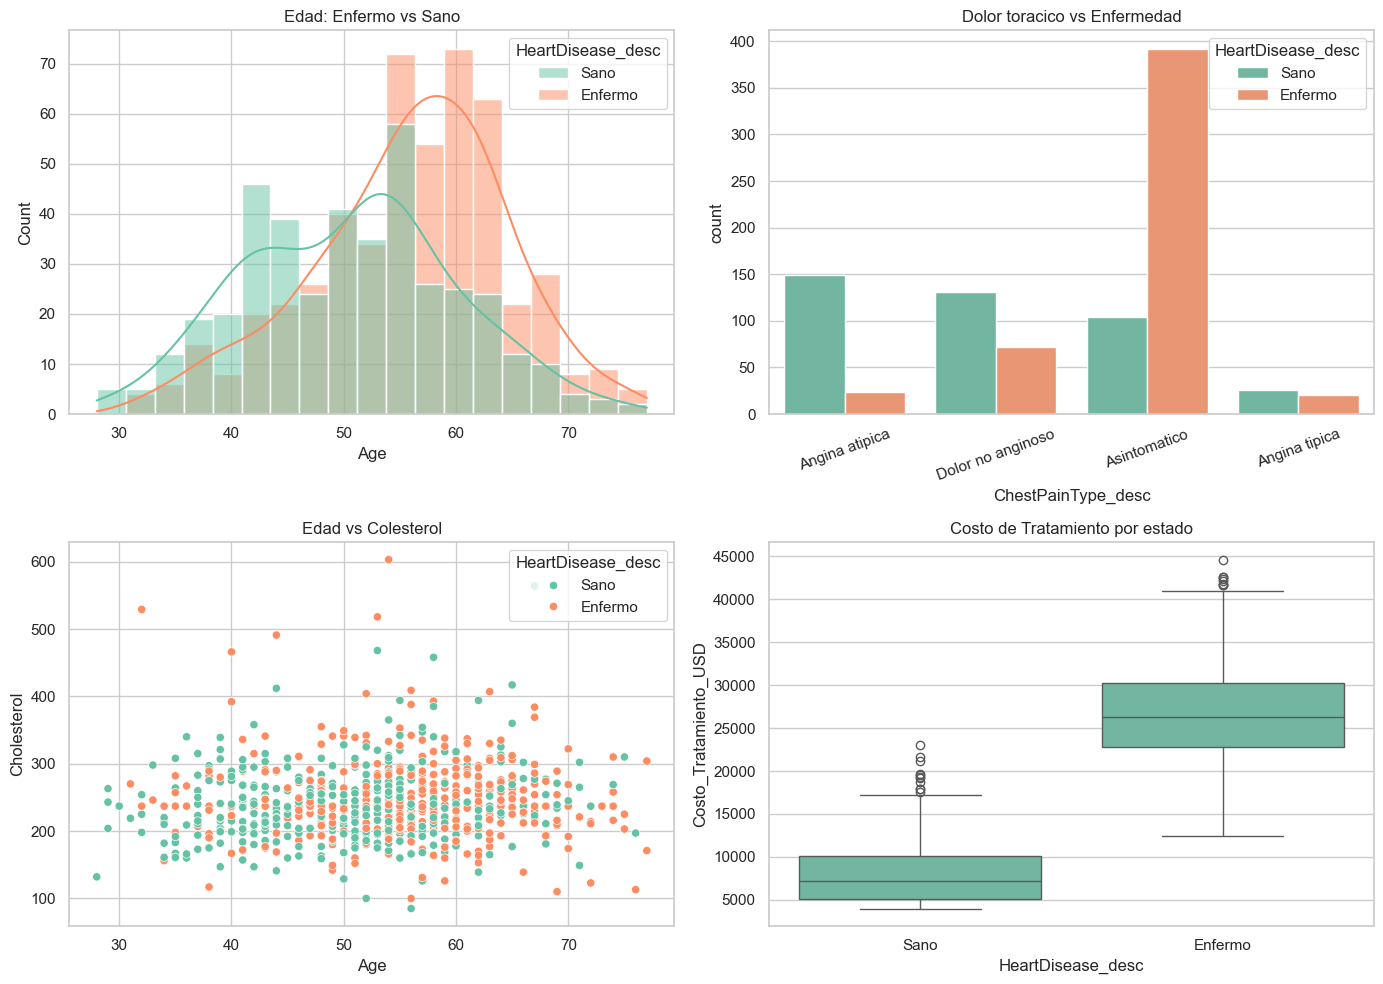

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df, x="Age", hue="HeartDisease_desc", kde=True, ax=axes[0,0])
axes[0,0].set_title("Edad: Enfermo vs Sano")
sns.countplot(df, x="ChestPainType_desc", hue="HeartDisease_desc", ax=axes[0,1])
axes[0,1].set_title("Dolor toracico vs Enfermedad"); axes[0,1].tick_params(axis="x", rotation=20)
sns.scatterplot(df, x="Age", y="Cholesterol", hue="HeartDisease_desc", ax=axes[1,0])
axes[1,0].set_title("Edad vs Colesterol")
sns.boxplot(df, x="HeartDisease_desc", y="Costo_Tratamiento_USD", ax=axes[1,1])
axes[1,1].set_title("Costo de Tratamiento por estado")
plt.tight_layout(); plt.show()

### Celda 9 - Guardar dataset preparado

In [ ]:
import os
os.makedirs("../output", exist_ok=True)
df.to_csv("../output/heart_preparado.csv", index=False)
print("Guardado '../output/heart_preparado.csv' -", df.shape[1], "columnas,", df.shape[0], "pacientes")

Guardado '../output/heart_preparado.csv' - 21 columnas, 918 pacientes
